<a href="https://colab.research.google.com/github/xseeker0/neural-scratchpad/blob/main/practice_7_3_1_TrOCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!python --version

Python 3.12.12


# TrOCR
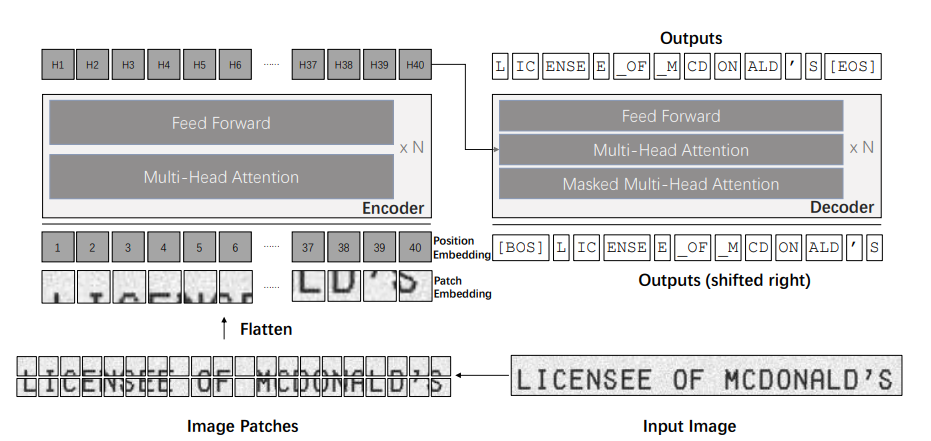

## Vision Encoder

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LRScheduler
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer
import timm
from datasets import load_dataset
from torchvision import transforms
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from torch.amp import autocast, GradScaler
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
class VisionEncoder(nn.Module):
    def __init__(self, model_name: str = 'deit_base_distilled_patch16_384', pretrained: bool = True):
        super().__init__()
        # Set num_classes=0 to remove the classification head and get raw features
        self.model = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        self.hidden_size = self.model.embed_dim

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        # Extract features (patch embeddings + cls/dist tokens)
        # Expected output shape: (batch_size, sequence_length, hidden_size)
        features = self.model.forward_features(pixel_values)
        return features

## Language Decoder

In [ ]:
class LanguageDecoder(nn.Module):
    def __init__(self, model_name: str = 'roberta-base', pretrained: bool = True):
        super().__init__()
        config = AutoConfig.from_pretrained(model_name)
        config.is_decoder = True
        config.add_cross_attention = True

        if pretrained:
            self.model = AutoModelForCausalLM.from_pretrained(model_name, config=config)
        else:
            self.model = AutoModelForCausalLM.from_config(config)
        self.hidden_size = config.hidden_size

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor = None, encoder_hidden_states: torch.Tensor = None) -> torch.Tensor:
        # Pass inputs and cross-attention states from the encoder
        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            encoder_hidden_states=encoder_hidden_states
        )
        return outputs.logits

## Model architecture

In [ ]:
class TrOCRModel(nn.Module):
    def __init__(self, encoder: nn.Module, decoder: nn.Module):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.projector = nn.Linear(encoder.hidden_size, decoder.hidden_size)

    def forward(self, pixel_values: torch.Tensor, decoder_input_ids: torch.Tensor, decoder_attention_mask: torch.Tensor = None) -> torch.Tensor:
        # 1. Image to visual patch embeddings
        x = self.encoder(pixel_values)
        x = self.projector(x)
        # 2. Text + Visual embeddings to logits
        logits = self.decoder(
            input_ids=decoder_input_ids,
            attention_mask=decoder_attention_mask,
            encoder_hidden_states=x
        )
        return logits

    @torch.no_grad()
    def generate(self, pixel_values: torch.Tensor, bos_token_id: int, eos_token_id: int, max_length: int = 128) -> torch.Tensor:
        device = pixel_values.device
        batch_size = pixel_values.size(0)
        encoder_hidden_states = self.encoder(pixel_values)
        encoder_hidden_states = self.projector(encoder_hidden_states)

        input_ids = torch.full((batch_size, 1), bos_token_id, dtype=torch.long, device=device)
        generated_ids = input_ids.clone()
        past_key_values = None
        unfinished_sequences = torch.ones(batch_size, dtype=torch.long, device=device)

        for _ in range(max_length):
            outputs = self.decoder.model(
                input_ids=input_ids,
                encoder_hidden_states=encoder_hidden_states,
                past_key_values=past_key_values,
                use_cache=True,
            )
            next_token_id = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)
            past_key_values = outputs.past_key_values
            input_ids = next_token_id
            generated_ids = torch.cat([generated_ids, next_token_id], dim=-1)
            unfinished_sequences = unfinished_sequences.mul(
                (next_token_id.squeeze(-1) != eos_token_id).long()
            )
            if unfinished_sequences.max() == 0:
                break

        return generated_ids

def count_parameters(model):
    """Prints the number of trainable parameters in the model."""
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print("-" * 30)
    print(f"Model Name: TrOCR-Base")
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print("-" * 30)

# encoder_name = "deit_base_distilled_patch16_384"
# decoder_name = "roberta-base"
# encoder_name = "deit_small_distilled_patch16_224"
# decoder_name = "microsoft/MiniLM-L12-H384-uncased"
# model = TrOCRModel(VisionEncoder(encoder_name), LanguageDecoder(decoder_name))
# print(model)
# count_parameters(model)

In [ ]:
# # Huggingface model
# from transformers import VisionEncoderDecoderModel
# # hf_trocr = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed')
# hf_trocr = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-small-handwritten')
# print(hf_trocr)
# count_parameters(hf_trocr)

## Load IAM Handwriting dataset

In [ ]:
raw = load_dataset("Teklia/IAM-line")
print(raw)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 6482
    })
    validation: Dataset({
        features: ['image', 'text'],
        num_rows: 976
    })
    test: Dataset({
        features: ['image', 'text'],
        num_rows: 2915
    })
})


In [ ]:
class OCRDataset(Dataset):
    """
    Wraps a HuggingFace dataset split.
    Each item returns:
        pixel_values  – (3, H, W) float tensor
        input_ids     – right-shifted decoder input  (BOS + tokens[:-1])
        labels        – tokens[1:] + EOS  (what the model should predict)
        attention_mask– mask for input_ids
    """

    IMG_SIZE = 224  # must match encoder patch size

    def __init__(self, hf_dataset, tokenizer, max_label_length: int = 128):
        self.data = hf_dataset
        self.tokenizer = tokenizer
        self.max_label_length = max_label_length
        self.transform = transforms.Compose([
            transforms.Resize((self.IMG_SIZE, self.IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # image
        image = item["image"]
        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)
        image = image.convert("RGB")
        pixel_values = self.transform(image)           # (3, H, W)

        # text tokens
        enc = self.tokenizer(
            item["text"],
            max_length=self.max_label_length,
            truncation=True,
            padding=False,
            return_tensors=None,
        )
        token_ids = enc["input_ids"]                   # includes BOS & EOS from tokeniser

        bos = self.tokenizer.bos_token_id or self.tokenizer.cls_token_id
        eos = self.tokenizer.eos_token_id or self.tokenizer.sep_token_id

        # Ensure BOS at front and EOS at end
        if token_ids[0] != bos:
            token_ids = [bos] + token_ids
        if token_ids[-1] != eos:
            token_ids = token_ids + [eos]

        # shift-right
        # decoder input  : [BOS, t1, t2, ..., t_{n-1}]
        # labels         : [t1,  t2, ..., t_{n-1}, EOS]
        decoder_input_ids = token_ids[:-1]
        labels            = token_ids[1:]

        pad = self.tokenizer.pad_token_id or 0
        max_len = self.max_label_length

        def pad_seq(seq):
            seq = seq[:max_len]
            mask = [1] * len(seq) + [0] * (max_len - len(seq))
            seq  = seq  + [pad]   * (max_len - len(seq))
            return seq, mask

        input_ids,  attn_mask = pad_seq(decoder_input_ids)
        label_ids, label_mask = pad_seq(labels)

        # Replace padding positions in labels with -100 (ignored by loss)
        label_ids = [l if m else -100 for l, m in zip(label_ids, label_mask)]

        return {
            "pixel_values":      pixel_values.detach().clone().float(),
            "input_ids":         torch.tensor(input_ids,      dtype=torch.long),
            "attention_mask":    torch.tensor(attn_mask,      dtype=torch.long),
            "labels":            torch.tensor(label_ids,      dtype=torch.long),
        }

## Ultils

In [ ]:
#  Label-smoothing cross-entropy loss
class LabelSmoothingCrossEntropy(nn.Module):
    """Cross-entropy with label smoothing. Ignores index -100."""

    def __init__(self, smoothing: float = 0.1, ignore_index: int = -100):
        super().__init__()
        self.smoothing = smoothing
        self.ignore_index = ignore_index

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        logits  : (B, T, V)
        targets : (B, T)
        """
        V = logits.size(-1)
        log_probs = torch.log_softmax(logits, dim=-1)           # (B, T, V)

        # Smooth target distribution
        with torch.no_grad():
            smooth_targets = torch.full_like(log_probs, self.smoothing / (V - 1))
            smooth_targets.scatter_(-1, targets.unsqueeze(-1).clamp(min=0), 1.0 - self.smoothing)

        # Per-token loss
        loss = -(smooth_targets * log_probs).sum(dim=-1)        # (B, T)

        # Mask ignored positions
        mask = targets.ne(self.ignore_index)
        loss = loss[mask].mean()
        return loss

def train_one_epoch(
    model, loader, optimizer, scheduler, scaler,
    criterion, device, accumulation_steps, epoch_idx
):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()

    pbar = tqdm(enumerate(loader), total=len(loader),
                desc=f"Epoch {epoch_idx+1} [train]", leave=True)

    for step, batch in pbar:
        pixel_values   = batch["pixel_values"].to(device)
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        with autocast(device_type=device.type):
            logits = model(pixel_values, input_ids, attention_mask)  # (B, T, V)
            loss   = criterion(logits, labels)
            loss   = loss / accumulation_steps

        scaler.scale(loss).backward()

        if (step + 1) % accumulation_steps == 0 or (step + 1) == len(loader):
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

        total_loss += loss.item() * accumulation_steps
        pbar.set_postfix(loss=f"{total_loss / (step + 1):.4f}",
                         lr=f"{scheduler.get_last_lr()[0]:.2e}")

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion, device, desc="[valid]"):
    model.eval()
    total_loss = 0.0

    pbar = tqdm(loader, desc=desc, leave=True)
    for batch in pbar:
        pixel_values   = batch["pixel_values"].to(device)
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        with autocast(device_type=device.type):
            logits = model(pixel_values, input_ids, attention_mask)
            loss   = criterion(logits, labels)

        total_loss += loss.item()
        pbar.set_postfix(loss=f"{total_loss / (pbar.n + 1):.4f}")

    return total_loss / len(loader)

In [ ]:
ENCODER_NAME = "deit_small_distilled_patch16_224"
DECODER_NAME = "microsoft/MiniLM-L12-H384-uncased"
MAX_LABEL_LENGTH = 64
PHYSICAL_BATCH = 128
TARGET_BATCH = 2048
ACCUMULATION_STEPS = TARGET_BATCH // PHYSICAL_BATCH
MAX_EPOCHS = 100
LR = 5e-5
WARMUP_RATIO = 0.10
LABEL_SMOOTHING = 0.1
VALID_RATIO = 0.10
SEED = 42
SAVE_DIR = "checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

# Early stopping config
PATIENCE = 7
MIN_DELTA = 1e-3
patience_counter = 0
early_stopped = False

torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(DECODER_NAME)
# Ensure special tokens exist
if tokenizer.bos_token is None:
    tokenizer.bos_token = tokenizer.cls_token
if tokenizer.eos_token is None:
    tokenizer.eos_token = tokenizer.sep_token
bos_id = tokenizer.bos_token_id
eos_id = tokenizer.eos_token_id

# Dataset
train_ds = OCRDataset(raw["train"], tokenizer, MAX_LABEL_LENGTH)
valid_ds = OCRDataset(raw["validation"], tokenizer, MAX_LABEL_LENGTH)
test_ds = OCRDataset(raw["test"], tokenizer, MAX_LABEL_LENGTH)

print(f"Train: {len(train_ds)} | Valid: {len(valid_ds)} | Test: {len(test_ds)}")

train_loader = DataLoader(
    train_ds, batch_size=PHYSICAL_BATCH, shuffle=True, num_workers=2, pin_memory=True
)
valid_loader = DataLoader(
    valid_ds, batch_size=PHYSICAL_BATCH, shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=PHYSICAL_BATCH, shuffle=False, num_workers=2, pin_memory=True
)

# Model
encoder = VisionEncoder(ENCODER_NAME, pretrained=True)
decoder = LanguageDecoder(DECODER_NAME, pretrained=True)
model = TrOCRModel(encoder, decoder).to(device)

# Optimizer & Scheduler
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

# Number of optimiser steps (one step per accumulation_steps mini-batches)
total_opt_steps = (len(train_loader) // ACCUMULATION_STEPS) * MAX_EPOCHS
warmup_steps = int(total_opt_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_opt_steps,
)
print(f"Total opt steps: {total_opt_steps} | Warmup steps: {warmup_steps}")

# Loss & AMP
criterion = LabelSmoothingCrossEntropy(smoothing=LABEL_SMOOTHING)
scaler = GradScaler()

## Training loop

In [ ]:
best_valid_loss = float("inf")
history = {"train_loss": [], "valid_loss": []}

for epoch in range(MAX_EPOCHS):
    train_loss = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler,
        criterion, device, ACCUMULATION_STEPS, epoch
    )
    valid_loss = evaluate(model, valid_loader, criterion, device,
                          desc=f"Epoch {epoch+1} [valid]")

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)

    print(f"\nEpoch {epoch+1}/{MAX_EPOCHS}  "
          f"train_loss={train_loss:.4f}  valid_loss={valid_loss:.4f}  "
          f"patience={patience_counter}/{PATIENCE}")

    # Checkpoint + early stopping
    if valid_loss < best_valid_loss - MIN_DELTA:
        best_valid_loss  = valid_loss
        patience_counter = 0
        ckpt_path = os.path.join(SAVE_DIR, "best_model.pt")
        torch.save({
            "epoch":                epoch + 1,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "valid_loss":           valid_loss,
        }, ckpt_path)
        print(f"Saved best checkpoint → {ckpt_path}")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch+1}.")
            early_stopped = True
            break

print("\nTraining complete." + (" (early stopped)" if early_stopped else ""))
print(f"Best validation loss: {best_valid_loss:.4f}")


Epoch 1 [valid]: 100%|██████████| 8/8 [00:04<00:00,  1.72it/s, loss=10.5349]



Epoch 1/100  train_loss=10.7822  valid_loss=10.5349  patience=0/7
Saved best checkpoint → checkpoints/best_model.pt


Epoch 2 [valid]: 100%|██████████| 8/8 [00:04<00:00,  1.84it/s, loss=9.4901]



Epoch 2/100  train_loss=10.3517  valid_loss=9.4901  patience=0/7
Saved best checkpoint → checkpoints/best_model.pt


Epoch 3 [valid]: 100%|██████████| 8/8 [00:08<00:00,  1.00s/it, loss=8.1732]


...


Epoch 61/100  train_loss=5.1429  valid_loss=5.7568  patience=4/7
No improvement. Patience: 5/7



Epoch 62 [valid]: 100%|██████████| 8/8 [00:04<00:00,  1.83it/s, loss=5.7521]


Epoch 62/100  train_loss=5.1322  valid_loss=5.7521  patience=5/7
No improvement. Patience: 6/7



Epoch 63 [valid]: 100%|██████████| 8/8 [00:05<00:00,  1.44it/s, loss=5.7606]


Epoch 63/100  train_loss=5.1258  valid_loss=5.7606  patience=6/7
No improvement. Patience: 7/7

Early stopping triggered at epoch 63.

Training complete. (early stopped)
Best validation loss: 5.7425


## Test

In [ ]:
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score

def _edit_distance(a: str, b: str) -> int:
    # Compute Levenshtein distance using dynamic programming
    la, lb = len(a), len(b)
    prev = list(range(lb + 1))
    for i in range(1, la + 1):
        curr = [i] + [0] * lb
        for j in range(1, lb + 1):
            if a[i - 1] == b[j - 1]:
                curr[j] = prev[j - 1]
            else:
                curr[j] = 1 + min(prev[j], curr[j - 1], prev[j - 1])
        prev = curr
    return prev[lb]

@torch.no_grad()
def evaluate_metrics(model, loader, tokenizer, device,
                     bos_token_id, eos_token_id,
                     max_gen_len=128, num_plot_samples=8):
    model.eval()
    all_preds, all_labels = [], []
    total_edit_dist, total_ref_chars = 0, 0
    ignore_ids = {tokenizer.pad_token_id, bos_token_id, eos_token_id}

    plot_refs, plot_preds = [], []

    for batch in tqdm(loader, desc="[test]"):
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"]

        generated = model.generate(
            pixel_values,
            bos_token_id=bos_token_id,
            eos_token_id=eos_token_id,
            max_length=max_gen_len
        )

        for i in range(labels.size(0)):
            ref_ids = [t.item() for t in labels[i]
                       if t.item() != -100 and t.item() not in ignore_ids]
            pred_ids = [t.item() for t in generated[i] if t.item() not in ignore_ids]

            pad = tokenizer.pad_token_id or 0
            max_l = max(len(ref_ids), len(pred_ids))
            all_labels.extend(ref_ids + [pad] * (max_l - len(ref_ids)))
            all_preds.extend(pred_ids + [pad] * (max_l - len(pred_ids)))

            ref_str = tokenizer.decode(ref_ids, skip_special_tokens=True)
            pred_str = tokenizer.decode(pred_ids, skip_special_tokens=True)
            total_edit_dist += _edit_distance(pred_str, ref_str)
            total_ref_chars += len(ref_str)

            if len(plot_refs) < num_plot_samples:
                plot_refs.append(ref_str)
                plot_preds.append(pred_str)

    pad_id = tokenizer.pad_token_id or 0
    mask = [l != pad_id for l in all_labels]
    fl = [l for l, m in zip(all_labels, mask) if m]
    fp = [p for p, m in zip(all_preds, mask) if m]

    precision = precision_score(fl, fp, average="micro", zero_division=0)
    recall = recall_score(fl, fp, average="micro", zero_division=0)
    f1 = f1_score(fl, fp, average="micro", zero_division=0)
    cer = total_edit_dist / max(total_ref_chars, 1)

    print(f"\n{'='*60}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  CER       : {cer:.4f}  ({cer*100:.2f}%)")
    print(f"{'='*60}")

    print(f"\n{'─'*60}")
    print(f"  SAMPLE PREDICTIONS  (first {len(plot_refs)} samples)")
    print(f"{'─'*60}")

    for idx, (ref, pred) in enumerate(zip(plot_refs, plot_preds)):
        match = "✓" if pred.strip() == ref.strip() else "✗"
        print(f"[{idx+1:02d}] {match}")
        print(f"  TRUE : {ref}")
        print(f"  PRED : {pred}\n")

    return {"precision": precision, "recall": recall, "f1": f1, "cer": cer}

In [ ]:
metrics = evaluate_metrics(
    model, test_loader, tokenizer, device,
    bos_token_id=bos_id, eos_token_id=eos_id,
    max_gen_len=MAX_LABEL_LENGTH,
    num_plot_samples=8
)

[test  ]: 100%|██████████| 23/23 [00:25<00:00,  1.11s/it]


  Precision : 0.0818
  Recall    : 0.0818
  F1 Score  : 0.0818
  CER       : 0.8063  (80.63%)

────────────────────────────────────────────────────────────
  SAMPLE PREDICTIONS  (first 8 samples)
────────────────────────────────────────────────────────────
[01] ✗
  TRUE : assuredness " " ( ), a lively song that changes tempo mid - way.
  PRED : ,, and,,,

[02] ✗
  TRUE : don ' t think he will storm the charts with this one, but it ' s a good start.
  PRED : , and the, and the,,

[03] ✗
  TRUE : , 39, who lives in - on -, is an accountant.
  PRED : ,,,,,

[04] ✗
  TRUE : a success with a disc and hey presto! ' re a star.... sings with
  PRED : , and the, and,,

[05] ✗
  TRUE : , as he is known in, likes songs with a month in the title. wrote
  PRED : , and, and the,

[06] ✗
  TRUE : ", " the big hit of 1956.
  PRED : ,, and,, and,

[07] ✗
  TRUE : is also a director of a couple of garages. he finds time as well to be a lyric
  PRED : , and the, and the,,

[08] ✗
  TRUE : writer. writes

# Test model with pre-trained

In [ ]:
from transformers import (
    VisionEncoderDecoderModel,
    TrOCRProcessor,
    AutoTokenizer,
)

class HFTrOCRModel(nn.Module):
    def __init__(self, model_name: str = "microsoft/trocr-small-stage1"):
        super().__init__()
        self.model = VisionEncoderDecoderModel.from_pretrained(model_name)
        config = self.model.config

        self.vocab_size = config.decoder.vocab_size

    def forward(
        self,
        pixel_values: torch.Tensor,
        decoder_input_ids: torch.Tensor,
        decoder_attention_mask: torch.Tensor = None,
    ) -> torch.Tensor:
        outputs = self.model(
            pixel_values=pixel_values,
            decoder_input_ids=decoder_input_ids,
            decoder_attention_mask=decoder_attention_mask,
        )
        return outputs.logits  # (B, T, V)

    @torch.no_grad()
    def generate(self, pixel_values, bos_token_id, eos_token_id, max_length=128):
        return self.model.generate(
            pixel_values,
            decoder_start_token_id=bos_token_id,
            bos_token_id=bos_token_id,
            eos_token_id=eos_token_id,
            max_new_tokens=max_length,
            pad_token_id=processor.tokenizer.pad_token_id,
        )

In [ ]:
from transformers import TrOCRProcessor

class HFOCRDataset(Dataset):
    def __init__(self, hf_dataset, processor: TrOCRProcessor, max_length: int = 64):
        self.data = hf_dataset
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        image = sample["image"].convert("RGB")
        text  = sample["text"]

        pixel_values = self.processor(
            images=image, return_tensors="pt"
        ).pixel_values.squeeze(0)

        tokenized = self.processor.tokenizer(
            text,
            padding="max_length",
            max_length=self.max_length,
            truncation=True,
            return_tensors="pt",
        )

        full_ids = tokenized.input_ids.squeeze(0)       # [BOS, t1, t2, ..., EOS, PAD, PAD]
        attention_mask = tokenized.attention_mask.squeeze(0)

        # Shift right
        input_ids = full_ids[:-1]                        # [BOS, t1, t2, ..., EOS]  decoder input
        labels    = full_ids[1:].clone()                 # [t1, t2, ..., EOS, PAD]  target

        # Mask padding trong labels
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            "pixel_values":   pixel_values,
            "input_ids":      input_ids,                 # length = max_length - 1
            "attention_mask": attention_mask[:-1],       # match input_ids length
            "labels":         labels,                    # length = max_length - 1
        }

In [ ]:
HF_MODEL_NAME = "microsoft/trocr-small-stage1"
MAX_LABEL_LENGTH = 64
PHYSICAL_BATCH = 64
TARGET_BATCH = 2048
ACCUMULATION_STEPS = TARGET_BATCH // PHYSICAL_BATCH
MAX_EPOCHS = 15

# Processor (image processor + tokenizer)
processor = TrOCRProcessor.from_pretrained(HF_MODEL_NAME)

# Dataset
train_ds_hf = HFOCRDataset(raw["train"],      processor, MAX_LABEL_LENGTH)
valid_ds_hf = HFOCRDataset(raw["validation"], processor, MAX_LABEL_LENGTH)
test_ds_hf  = HFOCRDataset(raw["test"],       processor, MAX_LABEL_LENGTH)

train_loader_hf = DataLoader(train_ds_hf, batch_size=PHYSICAL_BATCH, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader_hf = DataLoader(valid_ds_hf, batch_size=PHYSICAL_BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader_hf  = DataLoader(test_ds_hf,  batch_size=PHYSICAL_BATCH, shuffle=False, num_workers=2, pin_memory=True)

# Model
hf_model = HFTrOCRModel(HF_MODEL_NAME).to(device)

# Optimizer & scheduler
optimizer_hf = optim.AdamW(hf_model.parameters(), lr=LR, weight_decay=0.01)
total_opt_steps_hf = (len(train_loader_hf) // ACCUMULATION_STEPS) * MAX_EPOCHS
warmup_steps_hf    = int(total_opt_steps_hf * WARMUP_RATIO)

scheduler_hf = get_linear_schedule_with_warmup(
    optimizer_hf,
    num_warmup_steps=warmup_steps_hf,
    num_training_steps=total_opt_steps_hf,
)
print(f"Total steps: {total_opt_steps_hf} | Warmup: {warmup_steps_hf}")

criterion_hf = LabelSmoothingCrossEntropy(smoothing=LABEL_SMOOTHING)
scaler_hf    = GradScaler()

In [ ]:
# Train
best_valid_loss_hf = float("inf")
history_hf = {"train_loss": [], "valid_loss": []}

for epoch in range(MAX_EPOCHS):
    train_loss = train_one_epoch(
        hf_model, train_loader_hf, optimizer_hf, scheduler_hf,
        scaler_hf, criterion_hf, device, ACCUMULATION_STEPS, epoch
    )
    valid_loss = evaluate(
        hf_model, valid_loader_hf, criterion_hf, device,
        desc=f"Epoch {epoch+1} [valid]"
    )
    history_hf["train_loss"].append(train_loss)
    history_hf["valid_loss"].append(valid_loss)

Epoch 15 [valid]: 100%|██████████| 16/16 [00:09<00:00,  1.67it/s, loss=2.4328]


In [ ]:
hf_metrics = evaluate_metrics(
    model=hf_model,
    loader=test_loader_hf,                        # HFOCRDataset loader
    tokenizer=processor.tokenizer,
    device=device,
    bos_token_id=processor.tokenizer.bos_token_id,
    eos_token_id=processor.tokenizer.eos_token_id,
    max_gen_len=MAX_LABEL_LENGTH,
    num_plot_samples=8
)

[test]: 100%|██████████| 46/46 [01:16<00:00,  1.67s/it]



  Precision : 0.6073
  Recall    : 0.6073
  F1 Score  : 0.6073
  CER       : 0.1085  (10.85%)

────────────────────────────────────────────────────────────
  SAMPLE PREDICTIONS  (first 8 samples)
────────────────────────────────────────────────────────────
[01] ✗
  TRUE : assuredness " Bella Bella Marie " ( Parlophone ) , a lively song that changes tempo mid-way .
  PRED : surrendered " Bella Bella Horne " Carlophone , a truly song that damages tempo mid-way .

[02] ✗
  TRUE : I don't think he will storm the charts with this one , but it 's a good start .
  PRED : I don't think he will storm the charts with this one , but it's a good start .

[03] ✗
  TRUE : CHRIS CHARLES , 39 , who lives in Stockton-on-Tees , is an accountant .
  PRED : CHRIS CARRES , 39, who lives in Stockton-on - Tees , is an accountant .

[04] ✗
  TRUE : Become a success with a disc and hey presto ! You 're a star ... . Rolly sings with
  PRED : Become a success with a disc and hep press . You're a star ... .. Ral

In [ ]:
from google.colab import runtime
print("Shutting down now.")
runtime.unassign()

Shutting down now.
